## **Title:** Preparing Time Series Data for Forecasting

### Objective:

* Understand what makes time series data unique.
* Learn how to preprocess time series data for modeling.
* Explore indexing, sorting, resampling, handling missing data, and creating lag features.

### Dataset:

Use the Airline Passengers dataset
 URL: [https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv](https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv)


Let's begin your step-by-step demonstration of **Time Series Data Preparation**, starting with the **first task: DateTime Indexing**.

---

## **Task 1: DateTime Indexing**

### Objective:

Convert a regular column containing date information into a proper `datetime` format and **set it as the index** — which is essential for all time series operations.



In [ ]:
import pandas as pd

# Step 1: Load the dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Preview the data
print(df.head())


     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


### Step 2: Convert the 'Month' column to datetime

In [ ]:
df['Month'] = pd.to_datetime(df['Month'])


### Step 3: Set 'Month' as the DataFrame index

In [ ]:
df.set_index('Month', inplace=True)

In [ ]:
print(df.index)
print(df.head())

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


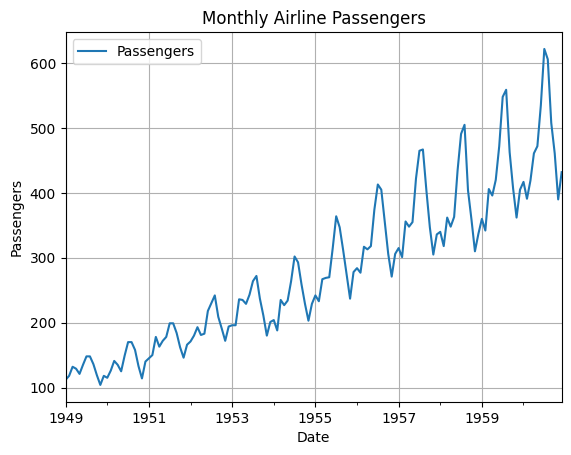

In [ ]:
import matplotlib.pyplot as plt

df.plot(title="Monthly Airline Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.grid(True)
plt.show()

Let’s proceed to the **next step** in time series data preparation:

## **Task 2: Checking and Handling Missing Timestamps**

---

### **Objective:**

Ensure your time series has **continuous time intervals** — no missing months, days, or weeks — which is **critical for forecasting models** and any form of temporal aggregation.

In [ ]:
print(df.head())

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


### Step 1: Generate a complete monthly date range

In [ ]:
# Create a full monthly date range from the start to the end of the dataset
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')

** `freq='MS'` = Month Start → ensures we expect one row **per month**.
** `full_range` will act as the **gold standard** against which we check if any timestamps are missing.

### Step 2: Reindex the DataFrame

In [ ]:
df = df.reindex(full_range)
df.index.name = 'Month'

* This forces the DataFrame to align with the full date range.
* Any **missing timestamps** will appear with **NaN values**.

---

### Step 3: Check for missing values


In [ ]:
missing_count = df['Passengers'].isna().sum()
print(f"Number of missing timestamps: {missing_count}")
print(df[df['Passengers'].isna()].head())

Number of missing timestamps: 0
Empty DataFrame
Columns: [Passengers]
Index: []


###  Step 4: Handle Missing Data

#### Option A: **Forward Fill (common in time series)**

In [ ]:
df['Passengers'].fillna(method='ffill', inplace=True)

<ipython-input-16-446315678>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Passengers'].fillna(method='ffill', inplace=True)
<ipython-input-16-446315678>:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Passengers'].fillna(method='ffill', inplace=True)


** Fills missing values with the **last known value**.

#### Option B: **Backward Fill**

In [ ]:
df['Passengers'].fillna(method='bfill', inplace=True)

<ipython-input-17-2901624995>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Passengers'].fillna(method='bfill', inplace=True)
<ipython-input-17-2901624995>:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Passengers'].fillna(method='bfill', inplace=True)


#### Option C: **Interpolate**

In [ ]:
df['Passengers'].interpolate(method='linear', inplace=True)

<ipython-input-18-2969720599>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Passengers'].interpolate(method='linear', inplace=True)


### Notes:

* If a forecasting model expects **evenly spaced time points**, reindexing is **non-negotiable**.
* Handling missing values is important to avoid errors during modeling (especially ARIMA, Prophet, etc.)

## **Task 3: Creating Time-Based Features (Month, Year, etc.)**

---

### **Objective:**

Extract **temporal components** (like year, month, day, weekday) from the datetime index, which helps capture **seasonality** and **time trends** in machine learning models.

These are especially useful for models that **don’t inherently understand time**, such as Decision Trees, Random Forests, or Gradient Boosting algorithms.

### Step 1: Extract time components

In [ ]:
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Quarter'] = df.index.quarter
df['DayOfWeek'] = df.index.dayofweek  # Monday=0, Sunday=6
df['Month_Name'] = df.index.strftime('%b')  # e.g., Jan, Feb

In [ ]:
print(df.head(12))

            Passengers  Year  Month  Quarter  DayOfWeek Month_Name
Month                                                             
1949-01-01         112  1949      1        1          5        Jan
1949-02-01         118  1949      2        1          1        Feb
1949-03-01         132  1949      3        1          1        Mar
1949-04-01         129  1949      4        2          4        Apr
1949-05-01         121  1949      5        2          6        May
1949-06-01         135  1949      6        2          2        Jun
1949-07-01         148  1949      7        3          4        Jul
1949-08-01         148  1949      8        3          0        Aug
1949-09-01         136  1949      9        3          3        Sep
1949-10-01         119  1949     10        4          5        Oct
1949-11-01         104  1949     11        4          1        Nov
1949-12-01         118  1949     12        4          3        Dec


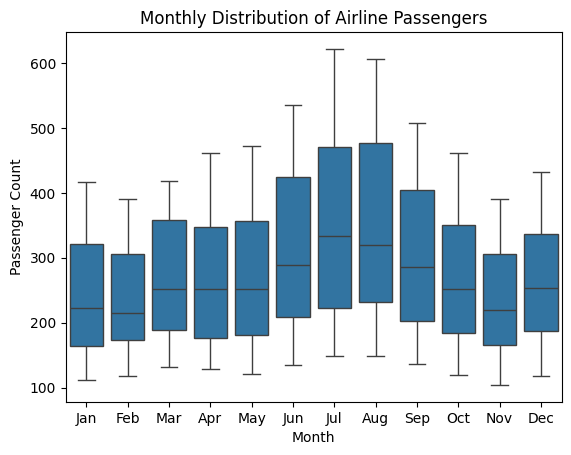

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Month_Name', y='Passengers', data=df.drop('Month', axis = 1).sort_values(by='Month'))
plt.title("Monthly Distribution of Airline Passengers")
plt.xlabel("Month")
plt.ylabel("Passenger Count")
plt.show()

**> This helps **visually detect seasonality** — do some months consistently have more traffic?

Let’s now move to one of the **most essential steps** in time series feature engineering:


##  **Task 4: Creating Lag Features**

---

### **Objective:**

Lag features introduce **temporal dependency** — allowing your model to learn from **past values**.

$$
\text{Lag}_t = \text{Value}_{t-k}
$$

Where `k` is the **lag interval** (e.g., 1 month ago, 12 months ago).

These are especially useful for:

* Supervised ML models (like Random Forests, XGBoost, etc.)
* Capturing autocorrelation
* Modeling seasonality (e.g., same month last year)


Let’s work on the `df` which already has:

* `Passengers` column
* Time-indexed format

---

### Step 1: Create basic lag features


In [ ]:
df['lag_1'] = df['Passengers'].shift(1)   # One period (month) back
df['lag_3'] = df['Passengers'].shift(3)   # Three months ago
df['lag_12'] = df['Passengers'].shift(12) # Same month last year

In [ ]:
print(df[['Passengers', 'lag_1', 'lag_3', 'lag_12']].head(15))

            Passengers  lag_1  lag_3  lag_12
Month                                       
1949-01-01         112    NaN    NaN     NaN
1949-02-01         118  112.0    NaN     NaN
1949-03-01         132  118.0    NaN     NaN
1949-04-01         129  132.0  112.0     NaN
1949-05-01         121  129.0  118.0     NaN
1949-06-01         135  121.0  132.0     NaN
1949-07-01         148  135.0  129.0     NaN
1949-08-01         148  148.0  121.0     NaN
1949-09-01         136  148.0  135.0     NaN
1949-10-01         119  136.0  148.0     NaN
1949-11-01         104  119.0  148.0     NaN
1949-12-01         118  104.0  136.0     NaN
1950-01-01         115  118.0  119.0   112.0
1950-02-01         126  115.0  104.0   118.0
1950-03-01         141  126.0  118.0   132.0


> Notice the first few rows of lag columns will be **NaN** because there is no data before them.

---

### Step 3: Drop rows with missing lag values

In [ ]:
df.dropna(inplace=True)

In [ ]:
correlations = df[['Passengers', 'lag_1', 'lag_3', 'lag_12']].corr()
print(correlations)

            Passengers     lag_1     lag_3    lag_12
Passengers    1.000000  0.954294  0.818664  0.990527
lag_1         0.954294  1.000000  0.882805  0.949238
lag_3         0.818664  0.882805  1.000000  0.821849
lag_12        0.990527  0.949238  0.821849  1.000000


In [ ]:
for lag in range(1, 13):
    df[f'lag_{lag}'] = df['Passengers'].shift(lag)

df.dropna(inplace=True)

## **Task 5: Creating Rolling/Averaging Features**

---

### **Objective:**

Rolling (or moving average) features **smooth out fluctuations** and capture **local trends**.
They’re useful for models that benefit from:

* Trend tracking
* Smoothing volatility
* Understanding local behaviors in noisy data



###  Step 1: Create a 3-month rolling average


In [ ]:
df['rolling_mean_3'] = df['Passengers'].rolling(window=3).mean()

* `window=3` → Takes the average of the **current and previous 2 months**.
* Useful to detect **quarterly trends** or reduce high-frequency noise.


### Step 2: Create other window sizes

In [ ]:
df['rolling_mean_6'] = df['Passengers'].rolling(window=6).mean()
df['rolling_mean_12'] = df['Passengers'].rolling(window=12).mean()

* These detect **half-yearly and yearly** moving trends.


###  Step 3: Preview results

In [ ]:
print(df[['Passengers', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12']].head(15))

            Passengers  rolling_mean_3  rolling_mean_6  rolling_mean_12
Month                                                                  
1951-01-01         145             NaN             NaN              NaN
1951-02-01         150             NaN             NaN              NaN
1951-03-01         178      157.666667             NaN              NaN
1951-04-01         163      163.666667             NaN              NaN
1951-05-01         172      171.000000             NaN              NaN
1951-06-01         178      171.000000      164.333333              NaN
1951-07-01         199      183.000000      173.333333              NaN
1951-08-01         199      192.000000      181.500000              NaN
1951-09-01         184      194.000000      182.500000              NaN
1951-10-01         162      181.666667      182.333333              NaN
1951-11-01         146      164.000000      178.000000              NaN
1951-12-01         166      158.000000      176.000000       170

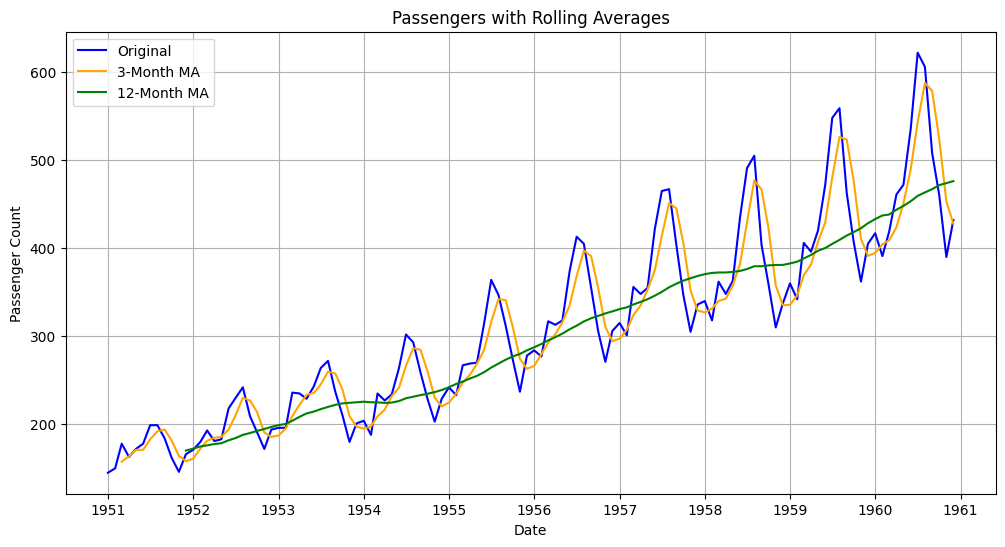

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Passengers'], label='Original', color='blue')
plt.plot(df['rolling_mean_3'], label='3-Month MA', color='orange')
plt.plot(df['rolling_mean_12'], label='12-Month MA', color='green')
plt.title("Passengers with Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Passenger Count")
plt.legend()
plt.grid(True)
plt.show()

### Caution:

* Rolling features **introduce NaNs** at the beginning → drop or handle appropriately:

In [ ]:
df.dropna(inplace=True)

A **very important concept** in time series modeling!

##  **Task 6: Train-Test Splitting in Time Series**

---

### 🎯 **Objective:**

Unlike standard ML datasets where we can randomly split data into train and test sets, **time series data must be split chronologically** to preserve temporal order.

This is because:

> You must **predict the future using the past**, not the other way around.



### Step 1: Understand the size of the dataset

In [ ]:
print(f"Total records: {len(df)}")

Total records: 109


Let’s assume we want to reserve the **last 12 months** (1 year) for testing.


In [ ]:
# Split index
train_size = len(df) - 12

# Chronologically split
train = df.iloc[:train_size]
test = df.iloc[train_size:]

This ensures:

* `train` only contains data **before** the test period.
* `test` simulates **real-world forecasting** (predicting future).

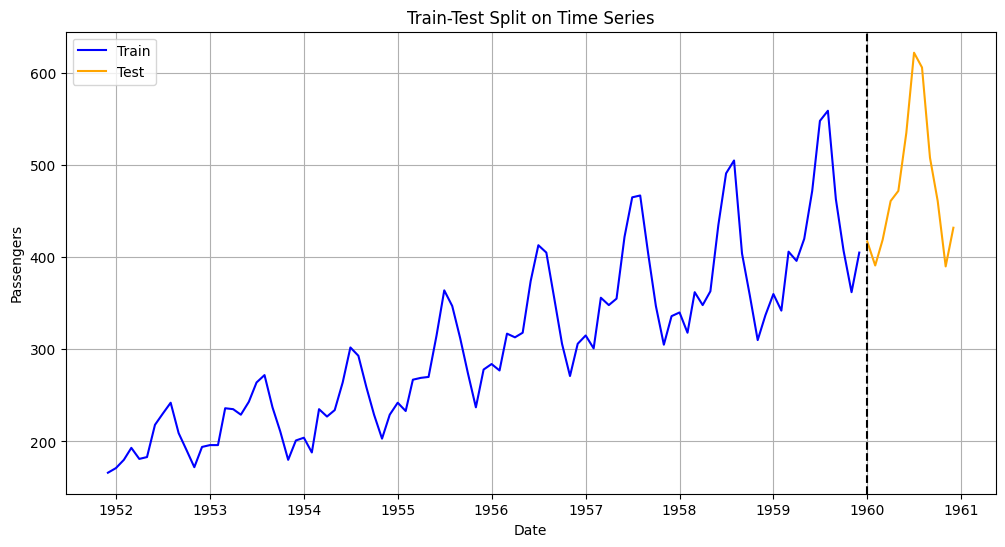

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='orange')
plt.axvline(test.index[0], color='black', linestyle='--')
plt.title("Train-Test Split on Time Series")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()

###  Why Not Use Random Split?

* Random split **breaks the time dependency**.
* You might be training on data that comes **after** the test period → a major data leakage issue.